# Candidate Problem Exploration: Review Prediction

**One problem, single framing:**

- **Question:** Can the star rating an order will receive be predicted from what is known once the order is delivered, so orders heading for a poor rating can be flagged before the customer disengages?
- **Framing (multi-class classification):** predict `review_score ∈ {1, 2, 3, 4, 5}`. The five classes collapse to any operational grouping (`bad = 1–2★`, or `{1}/{2–3}/{4–5}`) downstream.
- **Why review score:** unlike delivery lateness (measured against Olist's own gameable estimate), the rating is the customer's own verdict — an ungameable target — and its likely drivers (the realised delivery experience, shipping-cost burden, order value, seller track record) are in the data.
- **Stakeholder:** Customer-experience / after-sales team — wants an early flag on at-risk orders so it can reach out first, and to know which rating band to prioritise.

## At a glance

**What's in here.** The ~99k Olist reviews, deduped to **one independent opinion per order** (§1.1), joined to an order-level feature table (delivery timing, freight, price, size, distance, category, states) and restricted to delivered orders with a usable delivery time → **~95k orders**. Target: the 1–5 star rating as a **5-class** label (class share ≈ 10 / 3 / 8 / 20 / 59 %).

**Methods tried.** Multinomial Logistic Regression, Random Forest, HistGradientBoosting — all with balanced class weights. Evaluated with per-class recall, macro-F1, **adjacent accuracy** (±1★) and **quadratic weighted kappa** (QWK), since a 5★→1★ miss is worse than 5★→4★.

**Scores (held-out test).**

| Model | accuracy | macro-F1 | adjacent-acc | QWK | recall 1★ / 5★ |
|---|---|---|---|---|---|
| HistGB (balanced) | 0.44 | **0.29** | 0.74 | 0.33 | 0.46 / 0.55 |
| LogReg (balanced) | 0.42 | 0.27 | 0.68 | 0.29 | 0.43 / 0.55 |
| Random Forest (balanced) | 0.61 | 0.25 | 0.82 | 0.33 | 0.35 / 0.97 |

RF's accuracy is a mirage — it predicts 5★ for almost everything (2★–4★ recall ≈ 0). Balanced HistGB is the only model that meaningfully attempts all five classes. A binary `bad = 1–2★` view read off the HistGB argmax gets F1 ≈ 0.42.

**Limitations.**
- **The middle is unresolvable with these features.** 1★ and 5★ are found with fair skill; 2★/3★/4★ blur together — QWK stalls at ≈ 0.33.
- **Delivery timing is doing all the work** — `delivery_days` + `days_vs_estimate` alone match the full feature set; price, freight, weight, distance, category, state barely move it.
- Non-delivered orders (~2.8k opinions, mostly 1★) are excluded for lack of delivery features. Random split, no temporal hold-out.

## 0. Setup & Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
DATA_DIR = '../Olist_data'   # CSVs at repo root; this notebook runs from notebooks/

reviews   = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv',
                        parse_dates=['review_creation_date', 'review_answer_timestamp'])
orders    = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv',
                        parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date',
                                     'order_estimated_delivery_date'])
items     = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
products  = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
sellers   = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
geo       = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')
cat_tr    = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

# free-text fields are never model inputs (written at review time, mostly blank) -> drop them outright
reviews = reviews.drop(columns=['review_comment_title', 'review_comment_message'])

for n, d in [('reviews', reviews), ('orders', orders), ('order_items', items), ('products', products),
             ('sellers', sellers), ('customers', customers), ('geolocation', geo)]:
    print(f'{n:12} {d.shape[0]:>9,} rows  x {d.shape[1]} cols')

reviews         99,224 rows  x 5 cols
orders          99,441 rows  x 8 cols
order_items    112,650 rows  x 7 cols
products        32,951 rows  x 9 cols
sellers          3,095 rows  x 4 cols
customers       99,441 rows  x 5 cols
geolocation  1,000,163 rows  x 5 cols


## 1. Build & clean the modelling table

Three steps: check the `orders`↔`reviews` join and its key quirks (§1.0), dedup to one independent opinion per order (§1.1), then join order-level features and apply the modelling filters (§1.2).

### 1.0 Coverage — do >90% of orders really have a review?

Checking the join between `orders` and `reviews`: how many orders carry a review, how many reviews per order, and the known key quirks (a `review_id` shared by several orders, and vice versa).

In [3]:
n_orders = orders['order_id'].nunique()
print(f"orders total                  : {n_orders:,}")
print(f"review rows                   : {len(reviews):,}")
print(f"unique review_id              : {reviews['review_id'].nunique():,}")
print(f"unique order_id in reviews    : {reviews['order_id'].nunique():,}")
print(f"orders with >= 1 review       : {orders['order_id'].isin(reviews['order_id']).mean():.2%}")
print(f"fully duplicated review rows  : {reviews.duplicated().sum():,}")

rpo = reviews.groupby('order_id').size()
print(f"\nreviews per order:")
print(rpo.value_counts().sort_index().to_string())

rid = reviews.groupby('review_id')['order_id'].nunique()
oid = reviews.groupby('order_id')['review_id'].nunique()
print(f"\nreview_id linked to >1 order  : {(rid > 1).sum():,}")
print(f"order_id with >1 review_id    : {(oid > 1).sum():,}")

status = reviews.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
print(f"\nreview rows by order_status:")
print(status['order_status'].value_counts(dropna=False).to_string())

orders total                  : 99,441
review rows                   : 99,224
unique review_id              : 98,410
unique order_id in reviews    : 98,673
orders with >= 1 review       : 99.23%
fully duplicated review rows  : 0

reviews per order:
1    98126
2      543
3        4



review_id linked to >1 order  : 789
order_id with >1 review_id    : 547

review rows by order_status:
order_status
delivered      96361
shipped         1043
canceled         609
unavailable      597
invoiced         313
processing       296
created            3
approved           2


### 1.1 One independent opinion per order

Two quirks from the counts above:

- **789 `review_id`s are stapled onto 2–3 `order_id`s each.** One shopper's multi-seller checkout: Olist splits the cart into one order per seller (separate shipments) but sends a single review survey for the whole purchase. The sibling orders share the same `customer_unique_id` (each gets its own per-order `customer_id`), are placed seconds apart, and carry an identical review row.
- **547 `order_id`s carry 2–3 different `review_id`s** — the survey was answered again, or a reminder created a second review.

Dedup for the modelling table:
1. **One review per order** — keep the *first* (earliest `review_creation_date`); it is written soonest after delivery, closest to the features the model will use.
2. **One row per `review_id`** — collapse the stapled siblings, attaching the opinion to the earliest-purchased order of the checkout.

The descriptive sections below still run on the raw `reviews` table; `reviews_dedup` is what feeds the model.

In [4]:
# --- confirm the "multi-seller checkout" explanation for  review_id -> many orders ---
multi = reviews.groupby('review_id')['order_id'].nunique()
multi = multi[multi > 1]
sib = (reviews[reviews['review_id'].isin(multi.index)]
       .merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp']], on='order_id')
       .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id'))
same_uid = (sib.groupby('review_id')['customer_unique_id'].nunique() == 1).mean()
span_s   = sib.groupby('review_id')['order_purchase_timestamp'].agg(lambda s: (s.max() - s.min()).total_seconds())
print(f"multi-order review_ids                 : {len(multi):,}  (mostly 2 orders, a few 3)")
print(f"  all siblings same customer_unique_id : {same_uid:.0%}")
print(f"  siblings purchased within 60 s       : {(span_s <= 60).mean():.0%}")

# --- build the deduped 'one independent opinion per order' table ---
rv = reviews.sort_values(['review_creation_date', 'review_answer_timestamp', 'review_id'])
n0 = len(rv)
rv = rv.drop_duplicates('order_id', keep='first')                        # 1. order answered >1x -> keep the FIRST review
n1 = len(rv)
rv = (rv.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='left')
        .sort_values('order_purchase_timestamp')
        .drop_duplicates('review_id', keep='first'))                     # 2. review stapled to siblings -> keep one row
n2 = len(rv)
reviews_dedup = rv.drop(columns='order_purchase_timestamp')

print(f"\nreview rows                  : {n0:,}")
print(f"after 1x per order (first)   : {n1:,}  (-{n0 - n1:,})")
print(f"after 1x per review_id       : {n2:,}  (-{n1 - n2:,})")
print(f"unique review_id / order_id  : {reviews_dedup['review_id'].nunique():,} / {reviews_dedup['order_id'].nunique():,}")

multi-order review_ids                 : 789  (mostly 2 orders, a few 3)
  all siblings same customer_unique_id : 100%
  siblings purchased within 60 s       : 93%



review rows                  : 99,224
after 1x per order (first)   : 98,673  (-551)
after 1x per review_id       : 98,086  (-587)
unique review_id / order_id  : 98,086 / 98,086


### 1.2 Order-level feature table

Join the deduped opinions to one row per order: item aggregates (count, price, freight, weight, seller count, modal category), first seller's state, seller↔customer distance (haversine on mean zip-prefix coordinates), and delivery timing. Then the modelling filters:

- **delivered orders only** — non-delivered orders (~2.8k, overwhelmingly 1★) have no delivery features; a separate "never arrived" flag is left for Phase 2.
- **`delivery_days` in 0–60** — negative = data error, long tail = extreme exceptions (~0.3%).
- missing weights filled upstream (category median → global median); residual NaNs imputed in the pipeline.

Result: `model_df`, one row per delivered-and-reviewed order, target `review_score ∈ {1..5}`.

In [5]:
# --- order-level feature table for the deduped opinions ---
prod = products.merge(cat_tr, on='product_category_name', how='left')
prod['product_category_name_english'] = prod['product_category_name_english'].fillna('Unknown')
prod['product_weight_g'] = prod.groupby('product_category_name_english')['product_weight_g'].transform(
    lambda s: s.fillna(s.median()))
prod['product_weight_g'] = prod['product_weight_g'].fillna(prod['product_weight_g'].median())

it = items.merge(prod[['product_id', 'product_category_name_english', 'product_weight_g']], on='product_id', how='left')
first_seller = it.sort_values('order_item_id').groupby('order_id')['seller_id'].first()

oi = it.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    avg_weight=('product_weight_g', 'mean'),
    n_sellers=('seller_id', 'nunique'),
    category=('product_category_name_english', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
).reset_index()
oi['seller_id'] = oi['order_id'].map(first_seller)
oi = oi.merge(sellers[['seller_id', 'seller_state', 'seller_zip_code_prefix']], on='seller_id', how='left')

# seller <-> customer distance: mean lat/lng per zip prefix, then haversine
ga = geo.groupby('geolocation_zip_code_prefix').agg(lat=('geolocation_lat', 'mean'),
                                                    lng=('geolocation_lng', 'mean')).reset_index()
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = (reviews_dedup[['order_id', 'review_score']]
      .merge(orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
                     'order_delivered_customer_date', 'order_estimated_delivery_date']], on='order_id', how='left')
      .merge(customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')
      .merge(oi, on='order_id', how='left'))
df = df.merge(ga.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix', 'lat': 'clat', 'lng': 'clng'}),
              on='customer_zip_code_prefix', how='left')
df = df.merge(ga.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix', 'lat': 'slat', 'lng': 'slng'}),
              on='seller_zip_code_prefix', how='left')

df['distance_km']        = haversine(df['clat'], df['clng'], df['slat'], df['slng'])
df['delivery_days']      = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['days_vs_estimate']   = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days   # + = late
df['estimated_days']     = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days        # promised window
df['freight_ratio']      = df['total_freight'] / df['total_price'].replace(0, np.nan)
_pm = df['order_purchase_timestamp'].dt.to_period('M').astype('int64')
df['months_since_start'] = _pm - _pm.min()

# modelling filters
n0 = len(df)
model_df = df[df['order_status'] == 'delivered'].dropna(subset=['delivery_days', 'review_score']).copy()
n1 = len(model_df)
model_df = model_df[model_df['delivery_days'].between(0, 60)]                       # drop data errors / extreme tail
n2 = len(model_df)
model_df['review_score'] = model_df['review_score'].round().astype(int)

print(f"deduped opinions           : {n0:,}")
print(f"delivered + usable target  : {n1:,}  (-{n0 - n1:,}  — non-delivered orders, mostly 1*, excluded)")
print(f"delivery_days in 0-60      : {n2:,}  (-{n1 - n2:,})")
print("class share (%):", (model_df['review_score'].value_counts(normalize=True).sort_index() * 100).round(1).to_dict())
model_df.head()

deduped opinions           : 98,086
delivered + usable target  : 95,296  (-2,790  — non-delivered orders, mostly 1*, excluded)
delivery_days in 0-60      : 95,025  (-271)
class share (%): {1: 9.6, 2: 3.0, 3: 8.2, 4: 19.8, 5: 59.4}


,order_id,review_score,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_zip_code_prefix,n_items,total_price,total_freight,avg_weight,n_sellers,category,seller_id,seller_state,seller_zip_code_prefix,clat,clng,slat,slng,distance_km,delivery_days,days_vs_estimate,estimated_days,freight_ratio,months_since_start
3,bfbd0f9bdef84302105ad712db648a6c,1,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-11-09 07:47:38,2016-10-04,SP,14600,3.00,134.97,8.49,1000.00,1.00,health_beauty,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,81810.00,-20.59,-47.86,-25.51,-49.28,565.96,54.00,36.00,18,0.06,0
5,3b697a20d9e427646d92567910af6d57,4,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-26 14:02:13,2016-10-27,SP,4106,1.00,29.90,15.56,300.00,1.00,watches_gifts,522620dcb18a6b31cd7bdf73665113a9,PR,85801.00,-23.58,-46.64,-24.96,-53.46,708.75,23.00,-1.00,23,0.52,1
6,be5bc2f0da14d8071e2d45451ad119d9,4,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-27 18:19:38,2016-11-07,RS,98280,1.00,21.90,17.19,400.00,1.00,sports_leisure,f09b760d23495ac9a7e00d29b769007c,SP,15802.00,-28.29,-53.50,-21.14,-49.00,915.91,24.00,-11.00,34,0.78,1
8,a41c8759fbe7aab36ea07e038b2d4465,3,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-11-03 10:58:07,2016-11-29,RS,90040,1.00,36.49,17.24,767.00,1.00,sports_leisure,45d33f715e24d15a6ccf5c17b3a23e3c,SP,18015.00,-30.04,-51.21,-23.50,-47.43,818.15,30.00,-26.00,56,0.47,1
9,d207cc272675637bfed0062edffd0818,1,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-31 11:07:42,2016-11-23,SP,13185,1.00,119.90,13.56,2050.00,1.00,furniture_decor,cca3071e3e9bb7d12640c9fbe2301306,SP,14940.00,-22.89,-47.17,-21.76,-48.83,212.01,27.00,-23.00,50,0.11,1


## 2. Exploring the review score

Descriptive pass on the target — its shape, how it moves with the delivery experience, and which rating band matters most — before modelling.

### 2.1 Review score distribution

`review_score` is an integer 1–5, never null.

              count   pct
review_score             
1             11424 11.50
2              3151  3.20
3              8179  8.20
4             19142 19.30
5             57328 57.80

mean score       : 4.09
median score      : 5
score <= 2 (bad)  : 14.7%
score <= 3        : 22.9%
score == 5        : 57.8%
nulls in score    : 0


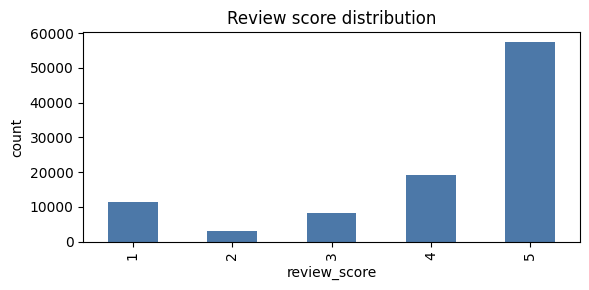

In [6]:
vc = reviews['review_score'].value_counts().sort_index()
dist = pd.DataFrame({'count': vc, 'pct': (vc / vc.sum() * 100).round(1)})
print(dist.to_string())
print(f"\nmean score       : {reviews['review_score'].mean():.2f}")
print(f"median score      : {reviews['review_score'].median():.0f}")
print(f"score <= 2 (bad)  : {(reviews['review_score'] <= 2).mean():.1%}")
print(f"score <= 3        : {(reviews['review_score'] <= 3).mean():.1%}")
print(f"score == 5        : {(reviews['review_score'] == 5).mean():.1%}")
print(f"nulls in score    : {reviews['review_score'].isna().sum()}")

ax = vc.plot(kind='bar', color='#4C78A8', figsize=(6, 3), title='Review score distribution')
ax.set_xlabel('review_score'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

### 2.2 Score vs. the delivery experience

One score per order (the deduped opinion). Bucketed by how the actual delivery landed against Olist's estimate — the effect is large and monotonic, which is why delivery timing heads the feature list.

In [7]:
o = orders[orders['order_status'] == 'delivered'].copy()
o['delivery_days']    = (o['order_delivered_customer_date'] - o['order_purchase_timestamp']).dt.days
o['days_vs_estimate'] = (o['order_delivered_customer_date'] - o['order_estimated_delivery_date']).dt.days

score_by_order = reviews.groupby('order_id')['review_score'].mean()
o = o.merge(score_by_order.rename('review_score'), on='order_id', how='inner')

o['delivery_bucket'] = pd.cut(o['days_vs_estimate'], [-10**6, -5, 0, 3, 10**6],
                              labels=['5+ d early', '0-5 d early', '1-3 d late', '4+ d late'])

tbl = o.groupby('delivery_bucket', observed=True)['review_score'].agg(
    mean_score='mean', n='size', pct_bad=lambda s: (s <= 2).mean())
print(tbl.round(3).to_string())

                 mean_score      n  pct_bad
delivery_bucket                            
5+ d early             4.31  81555     0.09
0-5 d early            4.12   7888     0.11
1-3 d late             3.29   1852     0.32
4+ d late              1.85   4529     0.75


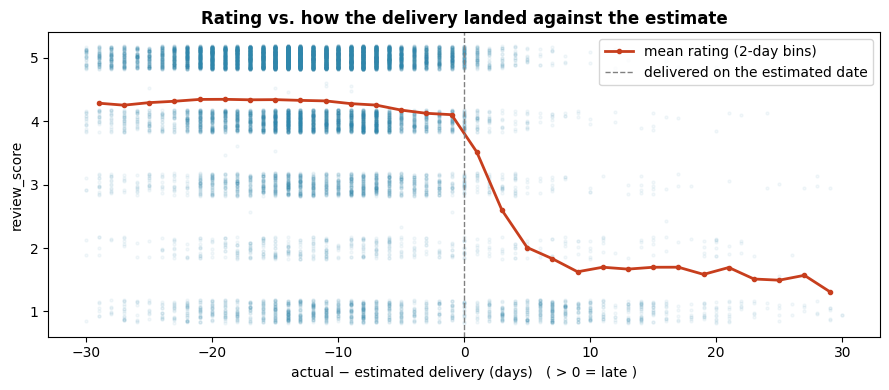

In [8]:
# scatter: rating vs. (actual - estimated) delivery days
rng = np.random.default_rng(0)
plot = o[o['days_vs_estimate'].between(-30, 30)].copy()
samp = plot.sample(min(15000, len(plot)), random_state=0)
jit = samp['review_score'] + rng.uniform(-0.18, 0.18, len(samp))

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(samp['days_vs_estimate'], jit, s=5, alpha=0.05, color='#2E86AB')

# mean rating in 2-day bins
plot['bin'] = pd.cut(plot['days_vs_estimate'], np.arange(-30, 31, 2))
m = plot.groupby('bin', observed=True)['review_score'].mean()
ax.plot([iv.mid for iv in m.index], m.values, color='#C73E1D', lw=2, marker='o', ms=3,
        label='mean rating (2-day bins)')

ax.axvline(0, color='grey', ls='--', lw=1, label='delivered on the estimated date')
ax.set_xlabel('actual − estimated delivery (days)   ( > 0 = late )')
ax.set_ylabel('review_score')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title('Rating vs. how the delivery landed against the estimate', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

### 2.3 Score over time and by category (brief)

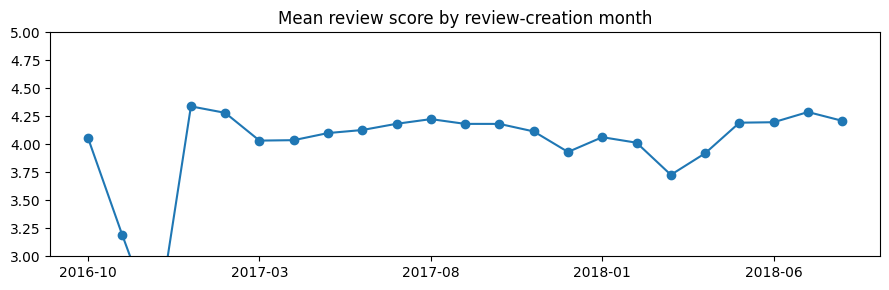

                               mean_score      n
product_category_name_english                   
bed_bath_table                       3.90  11137
furniture_decor                      3.90   8331
computers_accessories                3.93   7849
telephony                            3.95   4517
watches_gifts                        4.02   5950
garden_tools                         4.04   4329
housewares                           4.06   6943
auto                                 4.07   4213
sports_leisure                       4.11   8640
health_beauty                        4.14   9645
cool_stuff                           4.15   3772
toys                                 4.16   4091


In [9]:
monthly = reviews.groupby(reviews['review_creation_date'].dt.to_period('M'))['review_score'].mean()
monthly.index = monthly.index.astype(str)
ax = monthly.plot(figsize=(9, 3), marker='o', title='Mean review score by review-creation month')
ax.set_ylim(3, 5); ax.set_xlabel('')
plt.tight_layout(); plt.show()

it = items.merge(
    products.merge(cat_tr, on='product_category_name', how='left')[['product_id', 'product_category_name_english']],
    on='product_id', how='left')
it_rev = it.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
top = it_rev['product_category_name_english'].value_counts().head(12).index
cat_score = (it_rev[it_rev['product_category_name_english'].isin(top)]
             .groupby('product_category_name_english')['review_score']
             .agg(mean_score='mean', n='size').sort_values('mean_score'))
print(cat_score.round(2).to_string())

### 2.4 Which rating band matters most

The model predicts all five ratings, but after-sales can't chase everything. Two things decide the priority band:

1. **Score mix inside each delivery-outcome bucket** — a bad delivery doesn't spread evenly across 1–3★, it **collapses onto 1★** (≈65% of the "4+ days late" bucket). 1★ is the acute-failure signal.
2. **Class balance** if the five classes are grouped `{1} / {2–3} / {4–5}` — roughly 11 / 11 / 77 %, two workable minority bands.

So the operational read is: chase **1★** first; `{1} / {2–3} / {4–5}` is a sensible grouped head if the middle classes can't be separated (§4).

review_score        1    2     3     4     5
delivery_bucket                             
5+ d early       6.50 2.60  7.70 20.20 63.10
0-5 d early      7.80 3.50 11.80 22.40 54.50
1-3 d late      25.10 7.00 14.60 20.00 33.30
4+ d late       65.40 9.30  9.30  6.20  9.80


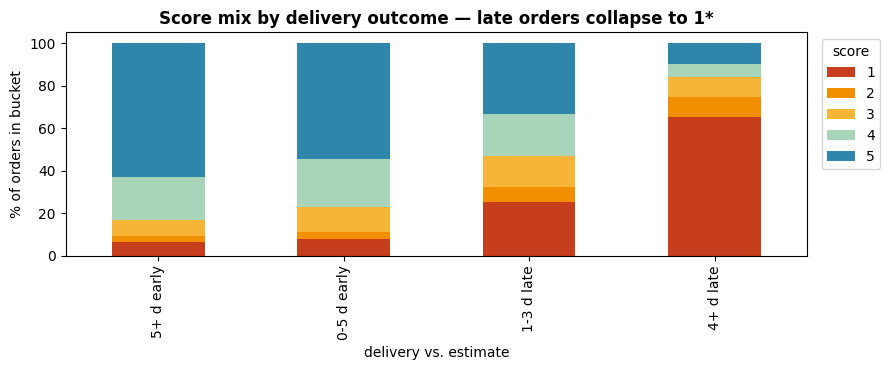


1*   (severe)  11.5%
2-3* (mid)     11.4%
4-5* (ok)      77.2%
(binary baseline  bad = 1-2* : 14.6%)


In [10]:
# score composition within delivery-outcome buckets  (does a bad delivery spread across 1-3*, or collapse to 1*?)
dv = orders[orders['order_status'] == 'delivered'].copy()
dv['days_vs_estimate'] = (dv['order_delivered_customer_date'] - dv['order_estimated_delivery_date']).dt.days
dv = dv.merge(reviews_dedup[['order_id', 'review_score']], on='order_id', how='inner')
dv['delivery_bucket'] = pd.cut(dv['days_vs_estimate'], [-10**6, -5, 0, 3, 10**6],
                               labels=['5+ d early', '0-5 d early', '1-3 d late', '4+ d late'])
comp = (dv.groupby('delivery_bucket', observed=True)['review_score']
          .value_counts(normalize=True).unstack().mul(100).round(1))
print(comp.to_string())

ax = comp.plot(kind='bar', stacked=True, figsize=(9, 3.8),
               color=['#C73E1D', '#F18F01', '#F7B538', '#A8D5BA', '#2E86AB'])
ax.set_title('Score mix by delivery outcome — late orders collapse to 1*', fontweight='bold')
ax.set_xlabel('delivery vs. estimate'); ax.set_ylabel('% of orders in bucket')
ax.legend(title='score', bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

# class balance of the proposed 3-class target
s = reviews_dedup['review_score']
print()
for name, frac in [('1*   (severe)', (s == 1).mean()),
                    ('2-3* (mid)',    s.between(2, 3).mean()),
                    ('4-5* (ok)',     s.between(4, 5).mean())]:
    print(f"{name:13} {frac:6.1%}")
print(f"(binary baseline  bad = 1-2* : {(s <= 2).mean():.1%})")

## 3. Modelling — 5-class baseline

**Target.** `review_score ∈ {1, 2, 3, 4, 5}`, multi-class. Heavily imbalanced (~10 / 3 / 8 / 20 / 59 %) and 2★ (~3k rows) has no crisp boundary with 1★ or 3★.

**Features.** Order + delivery attributes only — everything known once the order is delivered but before the review is written:
`n_items, total_price, total_freight, freight_ratio, avg_weight, n_sellers, distance_km, delivery_days, days_vs_estimate, estimated_days, months_since_start` + one-hot `category, customer_state, seller_state`.
Deliberately excluded: the review's own free text (dropped at load — written at review time, mostly blank) and any seller/product **rating history** (needs leakage-safe as-of aggregation — Phase 2).

**Models.** Multinomial LogReg / Random Forest / HistGradientBoosting, all `class_weight='balanced'`.

**Metrics.** Accuracy is misleading here (5★ dominates), so read: **per-class recall** (1★ is the one that matters), **macro-F1**, **adjacent accuracy** (within ±1 star), and **quadratic weighted kappa** — a 5★→1★ miss should cost more than 5★→4★.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = ['n_items', 'total_price', 'total_freight', 'freight_ratio', 'avg_weight', 'n_sellers',
            'distance_km', 'delivery_days', 'days_vs_estimate', 'estimated_days', 'months_since_start']
cat_cols = ['category', 'customer_state', 'seller_state']

X = model_df[num_cols + cat_cols]
y = model_df['review_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# dense one-hot so HistGradientBoosting is happy
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False))]), cat_cols),
])
print('train', X_train.shape, '  test', X_test.shape)
print('train class share (%):', (y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_dict())

train (76020, 14)   test (19005, 14)
train class share (%): {1: 9.6, 2: 3.0, 3: 8.2, 4: 19.8, 5: 59.4}


In [12]:
# --- baseline multi-class models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)

def adjacent_accuracy(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) <= 1))

clf_models = {
    'LogReg (balanced)':              LogisticRegression(class_weight='balanced', max_iter=2000),
    'Random Forest (balanced)':       RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                             n_jobs=-1, random_state=42),
    'HistGradientBoosting (balanced)': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
}

rows, fitted = [], {}
for name, model in clf_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = (pipe, pred)
    cm = confusion_matrix(y_test, pred, labels=[1, 2, 3, 4, 5])
    recall = cm.diagonal() / cm.sum(1)
    rows.append({
        'model': name,
        'accuracy':     round(accuracy_score(y_test, pred), 3),
        'macro_F1':     round(f1_score(y_test, pred, average='macro'), 3),
        'adjacent_acc': round(adjacent_accuracy(y_test, pred), 3),
        'QWK':          round(cohen_kappa_score(y_test, pred, weights='quadratic'), 3),
        'recall_1*':    round(recall[0], 2),
        'recall_5*':    round(recall[4], 2),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

                          model  accuracy  macro_F1  adjacent_acc  QWK  recall_1*  recall_5*
              LogReg (balanced)      0.42      0.27          0.68 0.29       0.43       0.55
       Random Forest (balanced)      0.61      0.25          0.82 0.33       0.35       0.97
HistGradientBoosting (balanced)      0.44      0.29          0.74 0.33       0.46       0.55


=== HistGradientBoosting (balanced) ===
              precision    recall  f1-score   support

           1      0.380     0.460     0.416      1819
           2      0.052     0.111     0.071       577
           3      0.105     0.146     0.122      1567
           4      0.227     0.262     0.243      3754
           5      0.681     0.548     0.608     11288

    accuracy                          0.437     19005
   macro avg      0.289     0.305     0.292     19005
weighted avg      0.496     0.437     0.461     19005



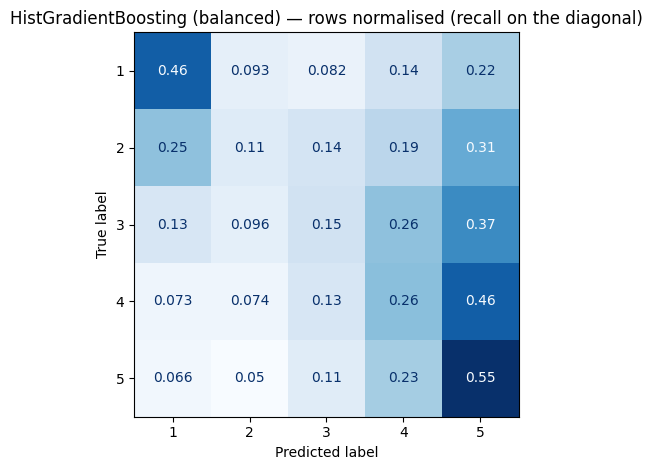

derived binary  bad = 1-2*   |  precision 0.35   recall 0.51   F1 0.42

Random Forest per-class recall: {1: np.float64(0.35), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.02), 5: np.float64(0.97)}


In [13]:
# --- working model = best macro-F1 (does it handle every class, not just 5*): report + confusion + binary view ---
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support

best = results.sort_values(['macro_F1', 'QWK'], ascending=False).iloc[0]['model']
pipe, pred = fitted[best]
print(f"=== {best} ===")
print(classification_report(y_test, pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=[1, 2, 3, 4, 5],
                                        normalize='true', cmap='Blues', colorbar=False)
plt.title(f'{best} — rows normalised (recall on the diagonal)')
plt.tight_layout(); plt.show()

# collapse the 5-class argmax to the operational bad = 1-2* flag
bad_true = (y_test <= 2).astype(int)
bad_pred = (pd.Series(pred, index=y_test.index) <= 2).astype(int)
p, r, f, _ = precision_recall_fscore_support(bad_true, bad_pred, average='binary')
print(f"derived binary  bad = 1-2*   |  precision {p:.2f}   recall {r:.2f}   F1 {f:.2f}")

# RandomForest ties HistGB on QWK only by predicting 5* for almost everything -- show its collapse
rf_pipe, rf_pred = fitted['Random Forest (balanced)']
rf_cm = confusion_matrix(y_test, rf_pred, labels=[1, 2, 3, 4, 5])
print("\nRandom Forest per-class recall:", dict(zip([1,2,3,4,5], (rf_cm.diagonal() / rf_cm.sum(1)).round(2))))

## 4. Notes for Phase 2

**Where the signal is.** Delivery timing carries almost all of it — a model on `delivery_days` + `days_vs_estimate` alone reaches QWK ≈ 0.31 vs ≈ 0.33 for the full feature set. Price, freight, weight, distance, category and state add little.

**What's stuck.** 5-class QWK ≈ 0.33 (fair), macro-F1 ≈ 0.29, adjacent accuracy ≈ 0.74. The model resolves the extremes (1★ recall ≈ 0.46, 5★ ≈ 0.55 with balanced HistGB) but 2★–3★–4★ stay a confusion band — expected from the fuzzy boundaries and the thin 2★ class.

**Not yet tried, worth a look:**
- *Seller / product rating history, done properly.* A naïve 5-fold out-of-fold seller mean score didn't help (noise on sparse sellers). Try an **as-of temporal** mean (only reviews from earlier-purchased orders) with empirical-Bayes shrinkage toward the global mean.
- *Fulfilment-stage lags* — `purchase → approved`, `approved → carrier`, `carrier → customer`; a slow hand-off may sour a review independently of the final lateness.
- *Ordinal models* — cumulative-link / `mord`, or regression-then-round, to use 1 < 2 < 3 < 4 < 5 directly instead of one-vs-rest.
- *Non-delivered orders* — currently excluded; ~2.8k opinions, overwhelmingly 1★. A separate "order failed to arrive" flag would catch them.
- *Ship the grouped head* — if 2★–4★ can't be separated, deploy the `{1} / {2–3} / {4–5}` model (§2.4) for operations and keep 5-class only for analysis.